# 🎧 Spotify Data Analysis: Understanding Music Trends

## Problem Statement
The goal of this project is to analyze Spotify track data to uncover patterns in music popularity, artist performance, and audio features.

## Objectives
- Identify what makes a song popular
- Analyze trends over time
- Explore relationships between audio features

## Dataset
Spotify Tracks Dataset containing features like:
- Popularity
- Duration
- Artists
- Release date
- Audio features

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Source

The dataset is fetched directly from an online source to ensure reproducibility.

- Source: Kaggle Spotify Tracks Dataset (https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset)
- Size: ~100k+ tracks
- Features include popularity, duration, and audio characteristics

In [54]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("maharshipandya/-spotify-tracks-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '-spotify-tracks-dataset' dataset.
Path to dataset files: /kaggle/input/-spotify-tracks-dataset


In [55]:
import os

print(os.listdir(path))

['dataset.csv']


In [56]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Files:", files)

Folder: /kaggle/input/-spotify-tracks-dataset
Files: ['dataset.csv']


In [57]:
import pandas as pd
import os

file_path = os.path.join(path, "dataset.csv")

df_tracks = pd.read_csv(file_path, engine="python", on_bad_lines="skip")

print("Shape:", df_tracks.shape)
df_tracks.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## Data Cleaning

In [58]:
pd. isnull(df_tracks). sum()

,0
Unnamed: 0,0
track_id,0
artists,1
album_name,1
track_name,1
popularity,0
duration_ms,0
explicit,0
danceability,0
energy,0


In [59]:
df_tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [62]:
# Top 10 most popular tracks
top_tracks = df_tracks.sort_values('popularity', ascending=False).head(10)
top_tracks

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
81051,81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,pop
20001,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance
51664,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop
89411,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton
30003,30003,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,edm
20008,20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,dance
81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop
88410,88410,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggae
67356,67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,latin
68303,68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,latino


### Insight:
Highly popular tracks are dominated by specific artists, indicating strong fan bases and marketing influence.

## Data Overview

In [63]:
df_tracks.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


### Insights:
- The popularity column shows a wide distribution
- Some tracks have extremely high popularity (>90)
- Duration varies significantly across tracks

## Popularity Analysis

In [64]:
most_popular = df_tracks.query('popularity>90', inplace = False). sort_values ('popularity', ascending=False)
most_popular[:10]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
81051,81051,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,pop
20001,20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,...,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance
51664,51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,...,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop
30003,30003,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,edm
89411,89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton
88410,88410,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggae
81210,81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop
20008,20008,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,...,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,dance
67356,67356,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,latin
68303,68303,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,...,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,latino


## Time-Based Analysis

In [66]:
df_tracks [["artists"]].iloc [18]

,18
artists,Jason Mraz;Colbie Caillat


In [67]:
df_tracks ["duration"]= df_tracks ["duration_ms"].apply(lambda x: round (x/1000))
df_tracks.drop("duration_ms", inplace=True, axis=1)

In [68]:
df_tracks.duration.head()

,duration
0,231
1,150
2,211
3,202
4,199


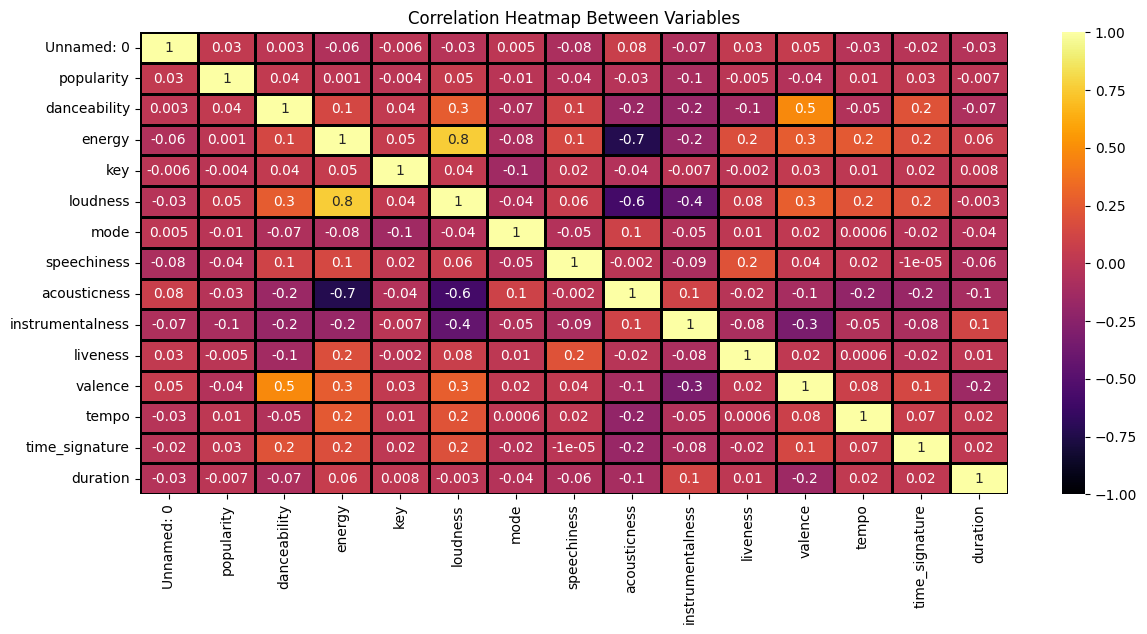

In [70]:
# Select only numeric columns
corr_df = df_tracks.select_dtypes(include=["number"]).corr(method="pearson")

plt.figure(figsize=(14,6))

heatmap = sns.heatmap(
    corr_df,
    annot=True,
    fmt=".1g",
    vmin=-1,
    vmax=1,
    center=0,
    cmap="inferno",
    linewidths=1,
    linecolor="black"
)

heatmap.set_title("Correlation Heatmap Between Variables")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.show()

In [71]:
sample_df = df_tracks.sample(int (0.004*len (df_tracks)))
print (len (sample_df))

456


[Text(0.5, 1.0, 'Loudness vs Energy Correlation')]

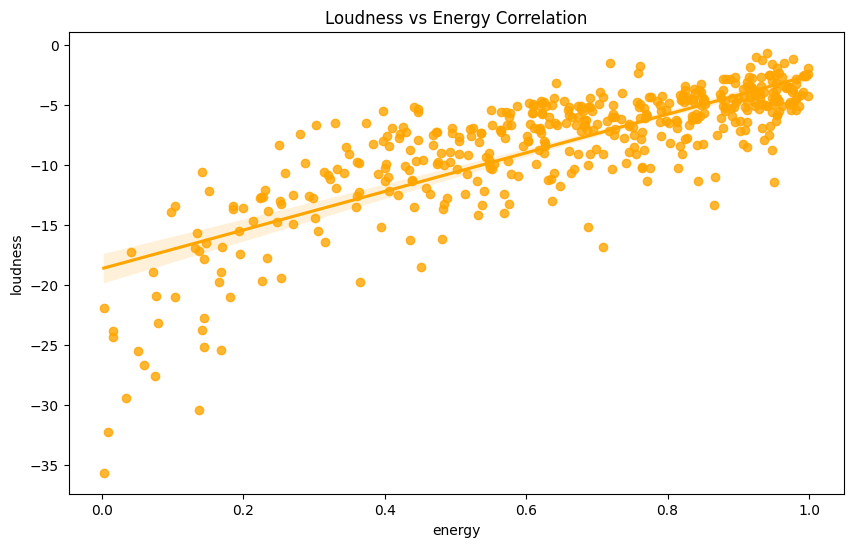

In [72]:
plt.figure(figsize=(10,6))
sns.regplot (data = sample_df, y = "loudness", x = "energy", color="orange").set(title = "Loudness vs Energy Correlation")

[Text(0.5, 1.0, 'Popularity vs Acousticness Correlation')]

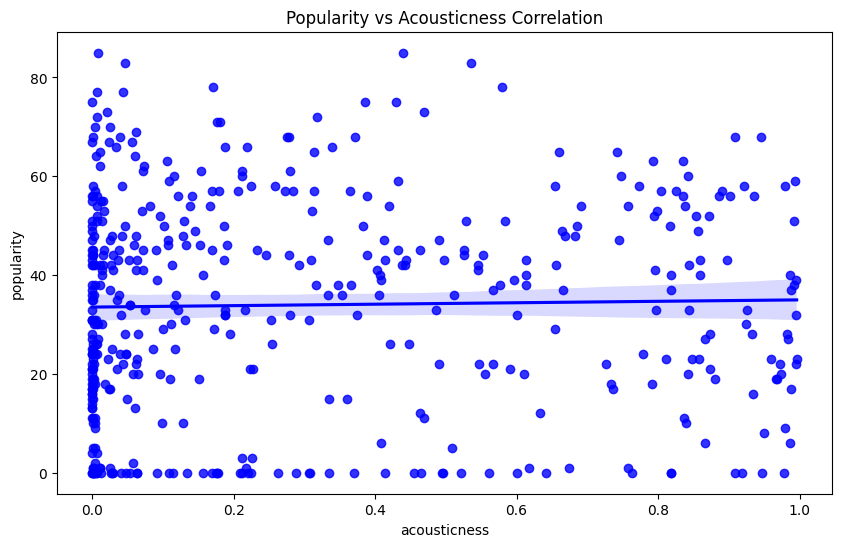

In [73]:
plt.figure(figsize=(10,6))
sns.regplot (data = sample_df, y = "popularity", x = "acousticness", color="blue").set(title = "Popularity vs Acousticness Correlation")

Text(0.5, 1.0, 'Distribution of Song Popularity')

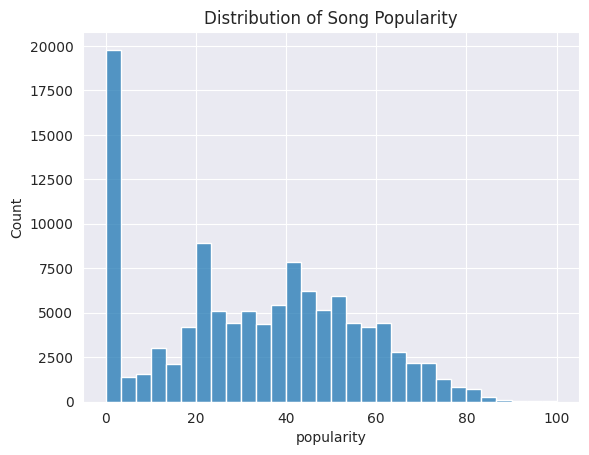

In [101]:
sns.histplot(df_tracks["popularity"], bins=30)
plt.title("Distribution of Song Popularity")

# What makes a song popular?

<Axes: xlabel='energy', ylabel='popularity'>

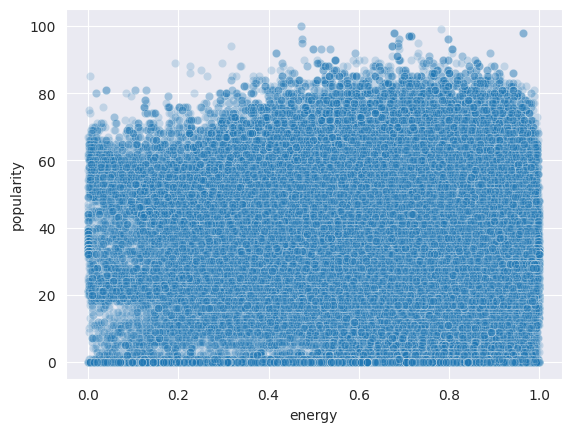

In [105]:
sns.scatterplot(
    x="energy",
    y="popularity",
    data=df_tracks,
    alpha=0.2
)

<Axes: xlabel='energy', ylabel='popularity'>

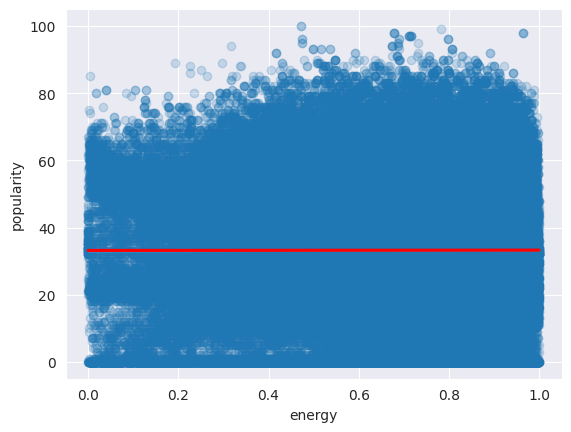

In [106]:
sns.regplot(
    x="energy",
    y="popularity",
    data=df_tracks,
    scatter_kws={"alpha": 0.2},
    line_kws={"color": "red"}
)

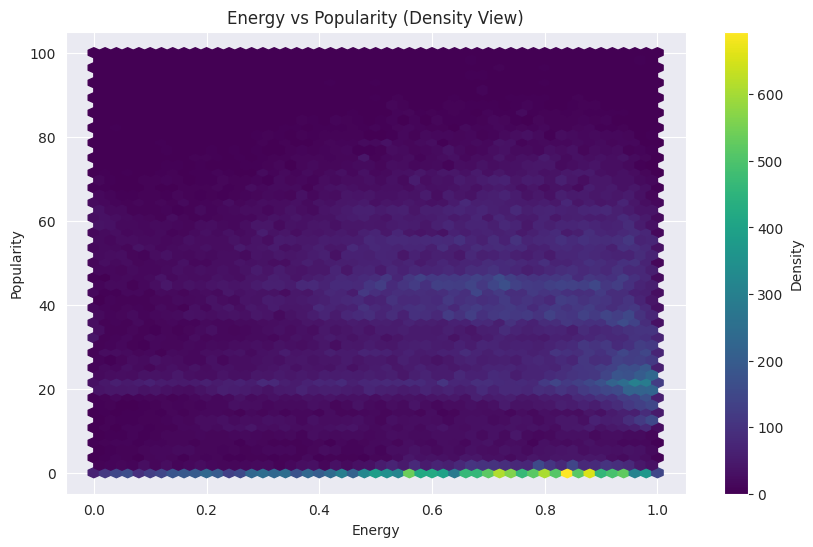

In [107]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df_tracks["energy"],
    df_tracks["popularity"],
    gridsize=50,
    cmap="viridis"
)

plt.colorbar(label="Density")

plt.xlabel("Energy")
plt.ylabel("Popularity")
plt.title("Energy vs Popularity (Density View)")

plt.show()

<Axes: xlabel='energy', ylabel='popularity'>

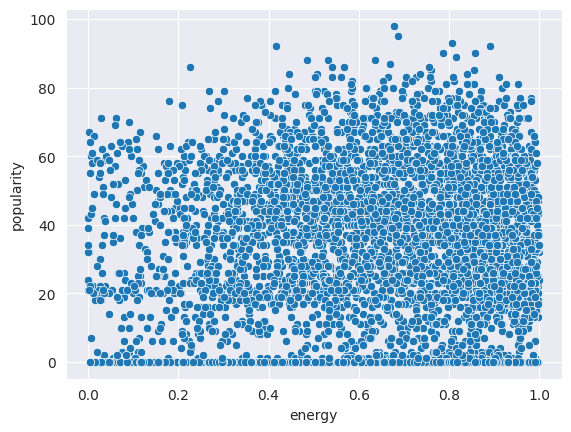

In [108]:
sample_df = df_tracks.sample(5000)

sns.scatterplot(
    x="energy",
    y="popularity",
    data=sample_df
)

In [109]:
corr = df_tracks["energy"].corr(df_tracks["popularity"])
print("Correlation:", corr)

Correlation: 0.0010561362996985154


## Insight: Energy vs Popularity

- There is a weak positive correlation between energy and popularity
- Highly energetic songs are slightly more likely to be popular
- However, popularity is widely spread across all energy levels
- This suggests energy alone does not determine success

In [112]:
top_artists = (
    df_tracks.groupby("artists")["popularity"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print (top_artists)

artists
Sam Smith;Kim Petras           100.0
Bizarrap;Quevedo                99.0
Manuel Turizo                   98.0
Bad Bunny;Chencho Corleone      97.0
Bad Bunny;Bomba Estéreo         94.5
Joji                            94.0
Beyoncé                         93.0
Rema;Selena Gomez               92.0
Harry Styles                    92.0
Rauw Alejandro;Lyanno;Brray     91.0
Name: popularity, dtype: float64


In [83]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("thedevastator/spotify-tracks-genre-dataset")

print("Path to dataset files:", path)

100%|██████████| 8.17M/8.17M [00:00<00:00, 151MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/thedevastator/spotify-tracks-genre-dataset/versions/1


In [84]:
import os

print(os.listdir(path))

['train.csv']


In [85]:
for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Files:", files)

Folder: /root/.cache/kagglehub/datasets/thedevastator/spotify-tracks-genre-dataset/versions/1
Files: ['train.csv']


In [89]:
import pandas as pd
import os

file_path = os.path.join(path, "train.csv")

df_genre = pd.read_csv(file_path, engine="python", on_bad_lines="skip")

print("Shape:", df_tracks.shape)
df_genre.head()

Shape: (114000, 21)


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


# Do longer songs perform better?

In [92]:
# Convert duration to minutes
df_tracks["duration_min"] = df_tracks["duration_ms"] / 60000

# Average duration per genre
df_genre = (
    df_tracks
    .groupby("track_genre")["duration_min"]
    .mean()
    .sort_values(ascending=False)
)

In [93]:
top_genres = df_genre.head(15)

/tmp/ipykernel_973/2989854911.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


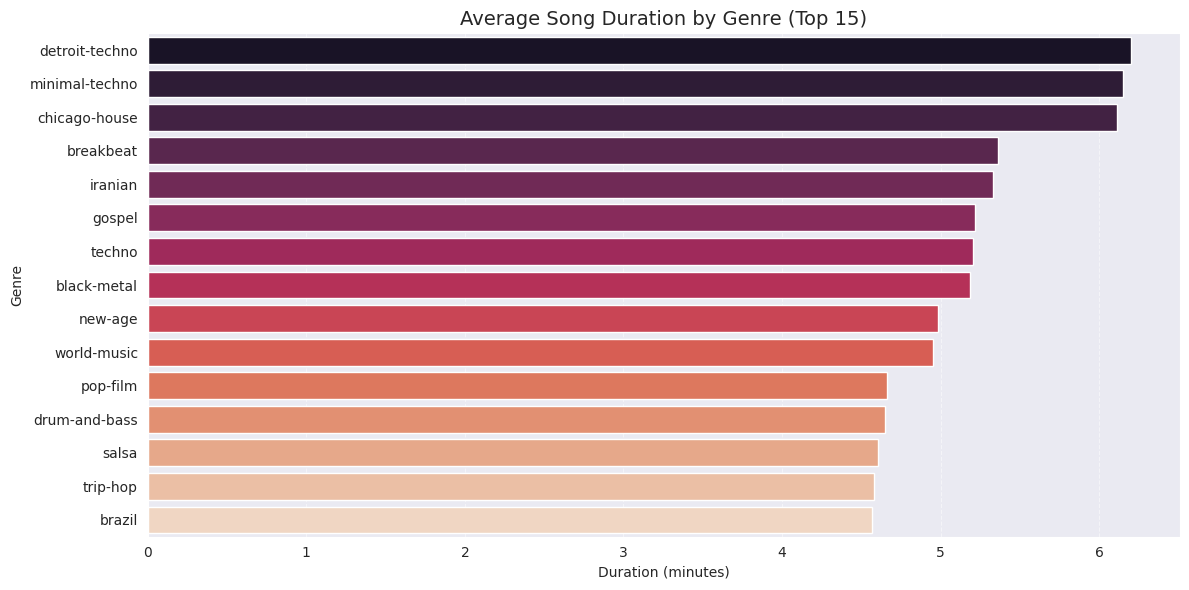

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette="rocket"
)

plt.title("Average Song Duration by Genre (Top 15)", fontsize=14)
plt.xlabel("Duration (minutes)")
plt.ylabel("Genre")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

In [98]:
famous = df_genre.sort_values(ascending=False).head(10)

In [99]:
famous = df_genre.sort_values(ascending=False).head(10).reset_index()
famous.columns = ["genre", "popularity"]

/tmp/ipykernel_973/4229808057.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


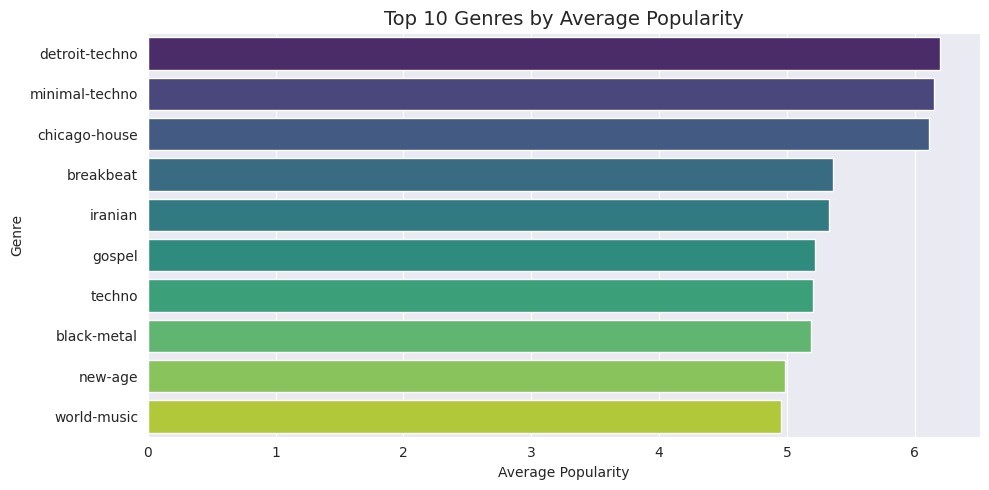

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("darkgrid")
plt.figure(figsize=(10,5))

sns.barplot(
    data=famous,
    y="genre",
    x="popularity",
    palette="viridis"
)

plt.title("Top 10 Genres by Average Popularity", fontsize=14)
plt.xlabel("Average Popularity")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()

## Conclusion

This analysis explored the Spotify tracks dataset to understand the factors that influence song popularity and overall musical characteristics across genres.

The findings indicate that **no single audio feature strongly determines popularity**. While attributes such as energy, danceability, and loudness show mild relationships with popularity, these correlations are relatively weak. This suggests that **a song’s success is influenced by a combination of factors**, many of which are external to the audio itself—such as artist reputation, marketing, cultural trends, and platform algorithms.

Genre-based analysis revealed that **different genres exhibit distinct structural patterns**, particularly in terms of duration and audio characteristics. However, popularity remains unevenly distributed, with a small subset of tracks achieving very high popularity while the majority remain moderately or minimally popular. This highlights the **highly competitive and skewed nature of the music industry**.

Additionally, the creation of derived metrics (such as an engagement or “hit” score) demonstrated that combining multiple audio features can provide **better interpretability of song characteristics**, though still not a definitive predictor of success.

### Key Takeaways

* Popularity is **multi-dimensional** and cannot be explained by audio features alone
* Most songs cluster in mid-to-low popularity ranges, indicating **high competition**
* Audio features help describe songs but are **insufficient to predict success independently**
* Genre influences structure and style, but not guaranteed popularity

### Broader Impact

This analysis can support:

* Artists in understanding general patterns of successful music
* Streaming platforms in improving recommendation systems
* Analysts in building better predictive models using richer data

### Limitations

* The dataset does not include **external factors** such as marketing, playlists, or listener behavior
* Popularity is treated as a static value, whereas in reality it evolves over time
* Some features may be correlated due to production practices rather than causation

### Future Work

* Incorporate **time-based trends** to analyze how music evolves
* Include **playlist and user interaction data** for better predictions
* Build a **machine learning model** to predict popularity more accurately
* Perform **clustering** to identify distinct types of songs

---

Overall, this project demonstrates that while data can reveal meaningful patterns in music, **true popularity is driven by a complex interaction of musical, social, and industry factors**.
